# Cell Activity Classification — Statistics & Distribution Analysis

This notebook analyses the output of the threshold-based activity classifier stored in:

- `cell_activity_percentile_90_otsu_per_instance.csv` — one row per segmented cell
- `cell_activity_percentile_90_otsu_summary.csv` — one row per image (z-slice)

Each row of `per_instance` is scoped by four identifiers: `sample`, `time`, `z_index`, and `label`. **A single image (z-slice) is uniquely identified by the `(sample, time, z_index)` triplet, and a single z-stack is uniquely identified by the `(sample, time)` tuple.** Aggregating across time is meaningless in a time-lapse experiment, so every aggregate below is scoped by `(sample, time)` (referred to as `sample_time`) rather than across the whole dataset.

The notebook produces:

1. Cell counts grouped by `(sample, time)` and by `(sample, time, z_index)`
2. Activity-metric distributions (clipped to the 99th percentile)
3. Per-z-index analysis, with per-`(sample, time)` traces
4. Per-sample analysis
5. **Time-ordered statistics** to detect temporal drift
6. Combined sample × z-index heatmaps (with optional down-sampling to 3–5 `(sample, time)` tuples when there would otherwise be too many entries)

Helpers are defined first, then applied to the loaded data in dedicated usage cells, following the style of `misc.ipynb`.


## 1. Imports & configuration

In [49]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Label text used in plots
active_label = "active"
dead_label = "dead"

# Percentile used to clip tails in distribution plots
CLIP_PERCENTILE = 0.99

# When there are many (sample, time) tuples, plots that would otherwise be too
# dense are down-sampled to this many representative pairs.
MAX_SAMPLE_TIME_PAIRS = 5


In [52]:
# Paths to the classifier output CSVs.
PER_INSTANCE_CSV = Path(
    "/Users/serenasritharan/Projects/single-cell/data/MF5V1_Timelapse_samples_processed/"
    "cell_activity_percentile_90_otsu_per_instance.csv"
)
SUMMARY_CSV = Path(
    "/Users/serenasritharan/Projects/single-cell/data/MF5V1_Timelapse_samples_processed/"
    "cell_activity_percentile_90_otsu_summary.csv"
)

# Metric used by the classifier (drives plot titles / axes)
threshold_metric = "percentile_90"


## 2. Load data

In [53]:
def _extract_z_from_name(name):
    if not isinstance(name, str):
        return np.nan
    for pattern in (r"_z(\d+)_", r"_z(\d+)\.", r"_z(\d+)$"):
        m = re.search(pattern, name)
        if m:
            return int(m.group(1))
    return np.nan


def _extract_sample_from_name(name):
    if not isinstance(name, str):
        return None
    m = re.search(r"_([A-H]\d{2})_", name)
    return m.group(1) if m else None


def _extract_time_from_name(name):
    if not isinstance(name, str):
        return np.nan
    m = re.search(r"_t(\d+)_", name)
    return int(m.group(1)) if m else np.nan


def _make_sample_time(df):
    """Add a helper column combining sample and time, e.g. 'C09_t11'."""
    sample = df["sample"].astype(str)
    time = df["time"].astype("Int64").astype(str)
    df["sample_time"] = sample + "_t" + time
    return df


def load_classifier_outputs(per_instance_path, summary_path):
    """Load per-instance and per-image CSVs and add helper columns."""
    metrics_df = pd.read_csv(per_instance_path)
    summary = pd.read_csv(summary_path)

    # Back-fill z_index / sample / time in per-instance if missing
    if "z_index" not in metrics_df.columns or metrics_df["z_index"].isna().any():
        metrics_df["z_index"] = metrics_df["image"].astype(str).apply(_extract_z_from_name)
    metrics_df["z_index"] = pd.to_numeric(metrics_df["z_index"], errors="coerce").astype("Int64")

    if "sample" not in metrics_df.columns or metrics_df["sample"].isna().any():
        metrics_df["sample"] = metrics_df["image"].astype(str).apply(_extract_sample_from_name)

    if "time" not in metrics_df.columns or metrics_df["time"].isna().any():
        metrics_df["time"] = metrics_df["image"].astype(str).apply(_extract_time_from_name)
    metrics_df["time"] = pd.to_numeric(metrics_df["time"], errors="coerce").astype("Int64")

    metrics_df = _make_sample_time(metrics_df)

    # Add z_index, sample, time, sample_time to the summary (derived from image name)
    summary["z_index"] = summary["image"].astype(str).apply(_extract_z_from_name)
    summary["z_index"] = pd.to_numeric(summary["z_index"], errors="coerce").astype("Int64")
    summary["sample"] = summary["image"].astype(str).apply(_extract_sample_from_name)
    summary["time"] = summary["image"].astype(str).apply(_extract_time_from_name)
    summary["time"] = pd.to_numeric(summary["time"], errors="coerce").astype("Int64")
    summary = _make_sample_time(summary)

    return metrics_df, summary


In [54]:
metrics_df, summary = load_classifier_outputs(PER_INSTANCE_CSV, SUMMARY_CSV)
print(f"per-instance rows: {len(metrics_df):,}  |  columns: {list(metrics_df.columns)}")
print(f"summary rows:      {len(summary):,}  |  columns: {list(summary.columns)}")
metrics_df.head()


per-instance rows: 2,385  |  columns: ['label', 'area', 'mean_intensity', 'max_intensity', 'min_intensity', 'sum_intensity', 'percentile_95', 'percentile_90', 'percentile_75', 'percentile_50', 'image', 'sample', 'z_index', 'ID', 'time', 'metric_value', 'threshold', 'is_active', 'sample_time']
summary rows:      107  |  columns: ['image', 'n_instances', 'n_active', 'n_dead', 'activity_ratio', 'metric_median', 'metric_mean', 'metric_std', 'threshold_used', 'percent_active', 'mcherry_path', 'brightfield_path', 'label_path', 'activity_path', 'z_index', 'sample', 'time', 'sample_time']


,label,area,mean_intensity,max_intensity,min_intensity,sum_intensity,percentile_95,percentile_90,percentile_75,percentile_50,image,sample,z_index,ID,time,metric_value,threshold,is_active,sample_time
0,8,508,172.897644,208.0,148.0,87832.0,189.00,186.0,180.00,172.0,pMF5V1_C09_t101_z10_mCherry.tif,C09,10,pMF5V1_C09_t101,101,186.0,314.059766,False,C09_t101
1,11,842,237.621140,316.0,180.0,200077.0,280.95,271.0,255.00,236.5,pMF5V1_C09_t101_z10_mCherry.tif,C09,10,pMF5V1_C09_t101,101,271.0,314.059766,False,C09_t101
2,14,278,183.748199,252.0,142.0,51082.0,222.00,211.0,193.00,180.0,pMF5V1_C09_t101_z10_mCherry.tif,C09,10,pMF5V1_C09_t101,101,211.0,314.059766,False,C09_t101
3,15,268,197.932831,236.0,156.0,53046.0,219.65,214.0,208.25,198.0,pMF5V1_C09_t101_z10_mCherry.tif,C09,10,pMF5V1_C09_t101,101,214.0,314.059766,False,C09_t101
4,16,160,168.837494,196.0,145.0,27014.0,185.05,181.1,175.00,168.0,pMF5V1_C09_t101_z10_mCherry.tif,C09,10,pMF5V1_C09_t101,101,181.1,314.059766,False,C09_t101


In [55]:
summary.head()


,image,n_instances,n_active,n_dead,activity_ratio,metric_median,metric_mean,metric_std,threshold_used,percent_active,mcherry_path,brightfield_path,label_path,activity_path,z_index,sample,time,sample_time
0,pMF5V1_C09_t101_z10_mCherry.tif,15,1,14,0.066667,205.0,228.740000,91.023928,314.059766,6.666667,C:\Install\split_data\split_data_subset\negati...,C:\Install\split_data\split_data_subset\negati...,C:\Install\final_2d\final_2d\pMF5V1_C09_t101_z...,C:\Install\final_2d\activity\pMF5V1_C09_t101_z...,10,C09,101,C09_t101
1,pMF5V1_C09_t101_z11_mCherry.tif,20,1,19,0.050000,183.3,206.175000,50.248047,314.059766,5.000000,C:\Install\split_data\split_data_subset\negati...,C:\Install\split_data\split_data_subset\negati...,C:\Install\final_2d\final_2d\pMF5V1_C09_t101_z...,C:\Install\final_2d\activity\pMF5V1_C09_t101_z...,11,C09,101,C09_t101
2,pMF5V1_C09_t101_z12_mCherry.tif,18,0,18,0.000000,182.5,198.333333,33.683649,314.059766,0.000000,C:\Install\split_data\split_data_subset\negati...,C:\Install\split_data\split_data_subset\negati...,C:\Install\final_2d\final_2d\pMF5V1_C09_t101_z...,C:\Install\final_2d\activity\pMF5V1_C09_t101_z...,12,C09,101,C09_t101
3,pMF5V1_C09_t101_z13_mCherry.tif,13,0,13,0.000000,181.0,188.138462,16.034834,314.059766,0.000000,C:\Install\split_data\split_data_subset\negati...,C:\Install\split_data\split_data_subset\negati...,C:\Install\final_2d\final_2d\pMF5V1_C09_t101_z...,C:\Install\final_2d\activity\pMF5V1_C09_t101_z...,13,C09,101,C09_t101
4,pMF5V1_C09_t101_z14_mCherry.tif,17,1,16,0.058824,179.0,204.876471,65.481128,314.059766,5.882353,C:\Install\split_data\split_data_subset\negati...,C:\Install\split_data\split_data_subset\negati...,C:\Install\final_2d\final_2d\pMF5V1_C09_t101_z...,C:\Install\final_2d\activity\pMF5V1_C09_t101_z...,14,C09,101,C09_t101


## 3. Dataset overview

High-level counts scoped by `(sample, time)` so that z-stacks from different time points remain distinct.

In [56]:
def dataset_overview(metrics_df, summary):
    n_cells = len(metrics_df)
    n_active = int(metrics_df["is_active"].sum())
    st_pairs = metrics_df[["sample", "time"]].drop_duplicates()

    return pd.Series({
        "total cells": n_cells,
        "active cells": n_active,
        "dead cells": n_cells - n_active,
        "overall activity rate": n_active / n_cells if n_cells else np.nan,
        "unique images (z-slices)": metrics_df["image"].nunique(),
        "unique samples": metrics_df["sample"].nunique(),
        "unique times": metrics_df["time"].nunique(),
        "unique (sample, time) pairs": len(st_pairs),
        "z-index range": f"{metrics_df['z_index'].min()}-{metrics_df['z_index'].max()}",
        "unique z-slices": metrics_df["z_index"].nunique(),
        "threshold (min .. max)": f"{metrics_df['threshold'].min():.2f} .. {metrics_df['threshold'].max():.2f}",
        "summary rows (images)": len(summary),
    })


def per_sample_time_overview(metrics_df):
    """Cells / active / rate / z-range per (sample, time)."""
    st = metrics_df.groupby(["sample", "time"]).agg(
        n_cells=("label", "count"),
        n_active=("is_active", "sum"),
        n_z=("z_index", "nunique"),
        z_min=("z_index", "min"),
        z_max=("z_index", "max"),
    )
    st["n_dead"] = st["n_cells"] - st["n_active"]
    st["activity_rate"] = st["n_active"] / st["n_cells"]
    return st.reset_index()


In [57]:
overview = dataset_overview(metrics_df, summary)
overview.to_frame("value")


,value
total cells,2385
active cells,203
dead cells,2182
overall activity rate,0.085115
unique images (z-slices),107
unique samples,1
unique times,7
"unique (sample, time) pairs",7
z-index range,1-20
unique z-slices,20


In [58]:
st_overview = per_sample_time_overview(metrics_df)
st_overview


,sample,time,n_cells,n_active,n_z,z_min,z_max,n_dead,activity_rate
0,C09,11,1336,180,20,1,20,1156,0.134731
1,C09,101,228,7,15,6,20,221,0.030702
2,C09,111,159,4,17,3,20,155,0.025157
3,C09,121,216,6,14,7,20,210,0.027778
4,C09,131,204,3,13,8,20,201,0.014706
5,C09,141,169,3,16,5,20,166,0.017751
6,C09,151,73,0,12,9,20,73,0.000000


## 4. Cell-count distributions by `(sample, time)`

Every aggregation in this section is keyed on the `(sample, time)` tuple so that z-stacks at different time points remain separated. Plots that would explode with many `(sample, time)` pairs are down-sampled to `MAX_SAMPLE_TIME_PAIRS` representative pairs.

In [59]:
def _pick_sample_time_pairs(df, k=MAX_SAMPLE_TIME_PAIRS):
    """Return up to `k` (sample, time) pairs spread across the dataset.

    If there are fewer than k pairs, returns all of them in stable order.
    Otherwise, picks pairs at roughly-even positions after sorting by sample
    then time so that the selection covers the full range.
    """
    pairs = (df[["sample", "time"]]
             .drop_duplicates()
             .sort_values(["sample", "time"])
             .reset_index(drop=True))
    if len(pairs) <= k:
        return pairs
    idx = np.linspace(0, len(pairs) - 1, num=k, dtype=int)
    return pairs.iloc[idx].reset_index(drop=True)


def _filter_to_pairs(df, pairs):
    keys = set(zip(pairs["sample"], pairs["time"]))
    mask = df[["sample", "time"]].apply(tuple, axis=1).isin(keys)
    return df[mask].copy()


def plot_cell_counts_by_sample_time(metrics_df):
    """Cells per (sample, time) + active vs dead + cells per z within each (sample, time)."""
    st = metrics_df.groupby(["sample_time"]).agg(
        n_cells=("label", "count"),
        n_active=("is_active", "sum"),
    )
    st["n_dead"] = st["n_cells"] - st["n_active"]
    st = st.sort_values("n_cells", ascending=False)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # (a) Total cells per (sample, time)
    ax = axes[0, 0]
    ax.bar(st.index, st["n_cells"], color="steelblue")
    ax.set_xlabel("(sample, time)")
    ax.set_ylabel("n cells")
    ax.set_title("Total cells per (sample, time)")
    ax.tick_params(axis="x", rotation=60)
    for i, v in enumerate(st["n_cells"]):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=8)

    # (b) Stacked active vs dead per (sample, time)
    ax = axes[0, 1]
    ax.bar(st.index, st["n_dead"], label=dead_label, color="#4C72B0")
    ax.bar(st.index, st["n_active"], bottom=st["n_dead"], label=active_label, color="#C44E52")
    ax.set_xlabel("(sample, time)")
    ax.set_ylabel("n cells")
    ax.set_title("Active vs dead per (sample, time)")
    ax.tick_params(axis="x", rotation=60)
    ax.legend()

    # (c) Histogram of the cells-per-(sample,time) distribution
    ax = axes[1, 0]
    sns.histplot(st["n_cells"], bins=min(20, max(5, len(st))), kde=len(st) > 5,
                 ax=ax, color="steelblue")
    ax.axvline(st["n_cells"].mean(), color="red", linestyle="--",
               label=f"mean = {st['n_cells'].mean():.1f}")
    ax.set_xlabel("cells per (sample, time)")
    ax.set_ylabel("n (sample, time) pairs")
    ax.set_title("Distribution of cells per (sample, time)")
    ax.legend()

    # (d) Activity rate per (sample, time)
    ax = axes[1, 1]
    rate = (st["n_active"] / st["n_cells"]) * 100
    ax.bar(rate.index, rate.values,
           color=["#55A868" if x > 50 else "#C44E52" if x < 20 else "#DD8452" for x in rate])
    ax.set_xlabel("(sample, time)")
    ax.set_ylabel("% active")
    ax.set_title("Activity rate per (sample, time)")
    ax.tick_params(axis="x", rotation=60)

    plt.tight_layout()
    plt.show()
    return st


def plot_cells_per_z_by_sample_time(metrics_df, k=MAX_SAMPLE_TIME_PAIRS):
    """Cells per z-index, as separate traces for each (sample, time) tuple.

    If the number of (sample, time) pairs exceeds `k`, only `k` representative
    pairs are drawn.
    """
    pairs = _pick_sample_time_pairs(metrics_df, k=k)
    sub = _filter_to_pairs(metrics_df, pairs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # (a) Total cells per z-index, one line per (sample, time)
    ax = axes[0]
    counts = (sub.groupby(["sample_time", "z_index"])
                 .size().reset_index(name="n_cells"))
    for st, grp in counts.groupby("sample_time"):
        grp_sorted = grp.sort_values("z_index")
        ax.plot(grp_sorted["z_index"].astype(int), grp_sorted["n_cells"],
                marker="o", linewidth=1.5, markersize=5, label=st)
    ax.set_xlabel("z-index")
    ax.set_ylabel("n cells")
    n_total = metrics_df[["sample", "time"]].drop_duplicates().shape[0]
    extra = f" (showing {len(pairs)} of {n_total} pairs)" if n_total > len(pairs) else ""
    ax.set_title(f"Cells per z-index, per (sample, time){extra}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

    # (b) Active vs dead per z-index, stacked, per (sample, time)
    ax = axes[1]
    counts = (sub.groupby(["sample_time", "z_index", "is_active"])
                 .size().reset_index(name="n"))
    pivot = (counts.pivot_table(index=["sample_time", "z_index"], columns="is_active",
                                values="n", fill_value=0)
                    .reset_index())
    # Plot as stacked bars keyed on "sample_time-z_index"
    pivot = pivot.sort_values(["sample_time", "z_index"])
    x_labels = [f"{st}_z{int(z)}" for st, z in zip(pivot["sample_time"], pivot["z_index"])]
    ax.bar(x_labels, pivot.get(False, 0), color="#4C72B0", label=dead_label)
    ax.bar(x_labels, pivot.get(True, 0),
           bottom=pivot.get(False, 0), color="#C44E52", label=active_label)
    ax.set_xlabel("(sample, time, z)")
    ax.set_ylabel("n cells")
    ax.set_title(f"Active vs dead per z-index, per (sample, time){extra}")
    ax.tick_params(axis="x", rotation=80, labelsize=6)
    ax.legend()

    plt.tight_layout()
    plt.show()
    return counts


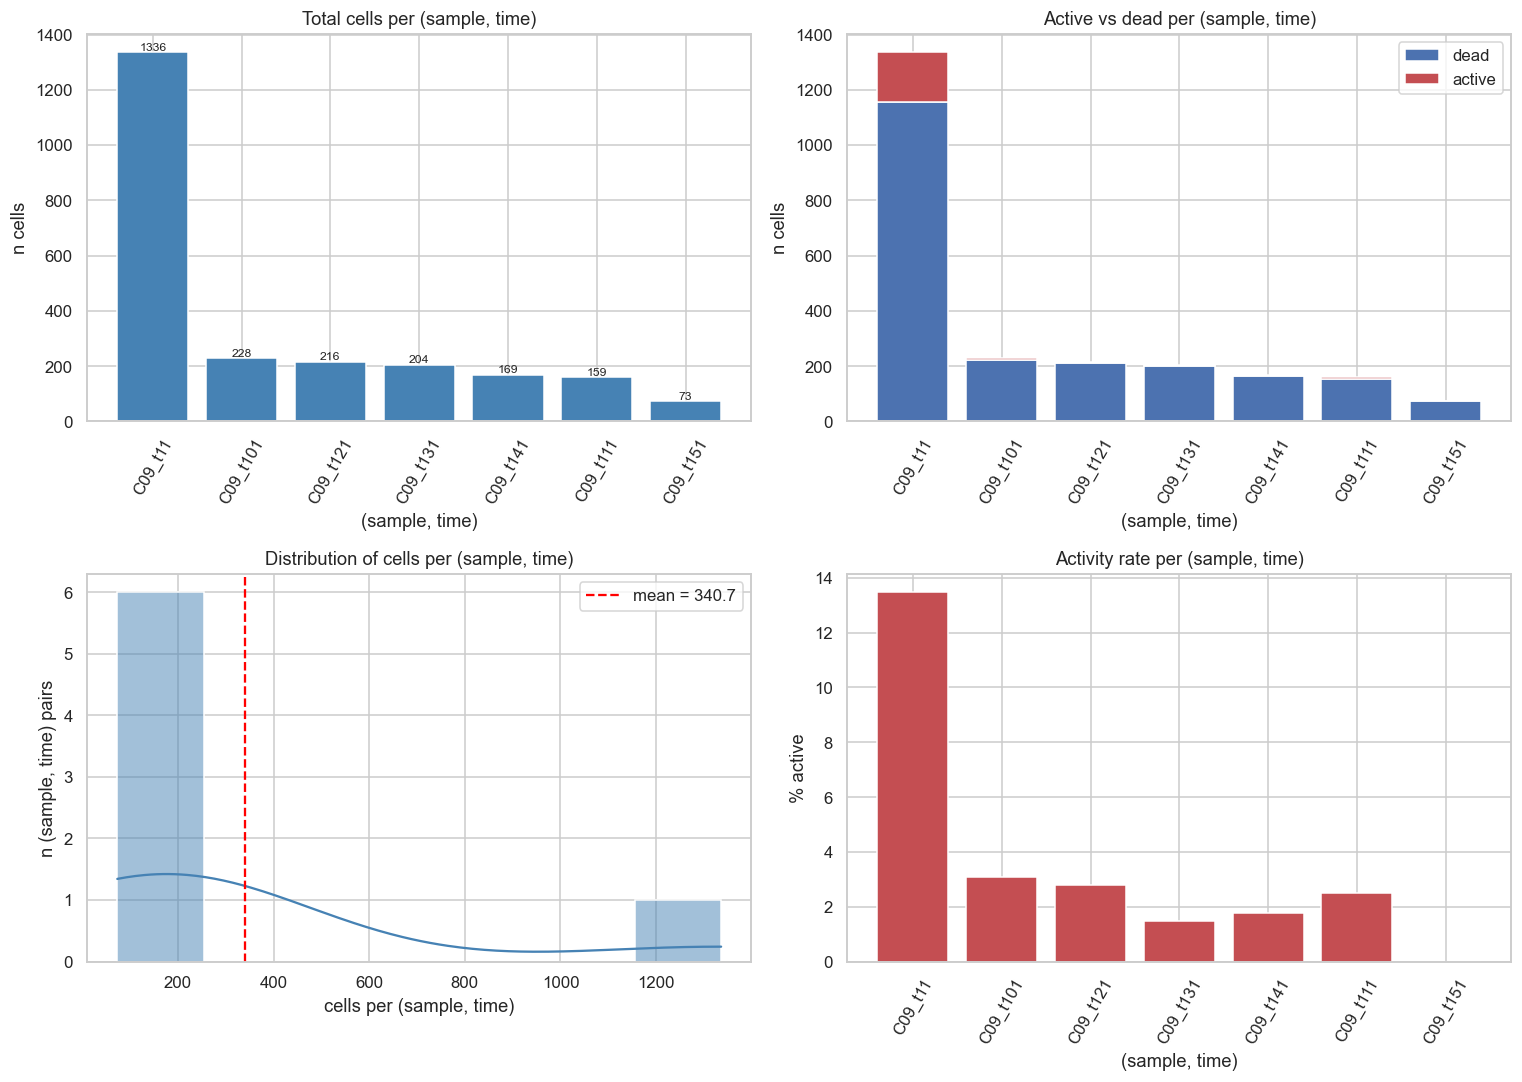

,n_cells,n_active,n_dead
sample_time,,,
C09_t11,1336,180,1156
C09_t101,228,7,221
C09_t121,216,6,210
C09_t131,204,3,201
C09_t141,169,3,166
C09_t111,159,4,155
C09_t151,73,0,73


In [60]:
st_counts = plot_cell_counts_by_sample_time(metrics_df)
st_counts


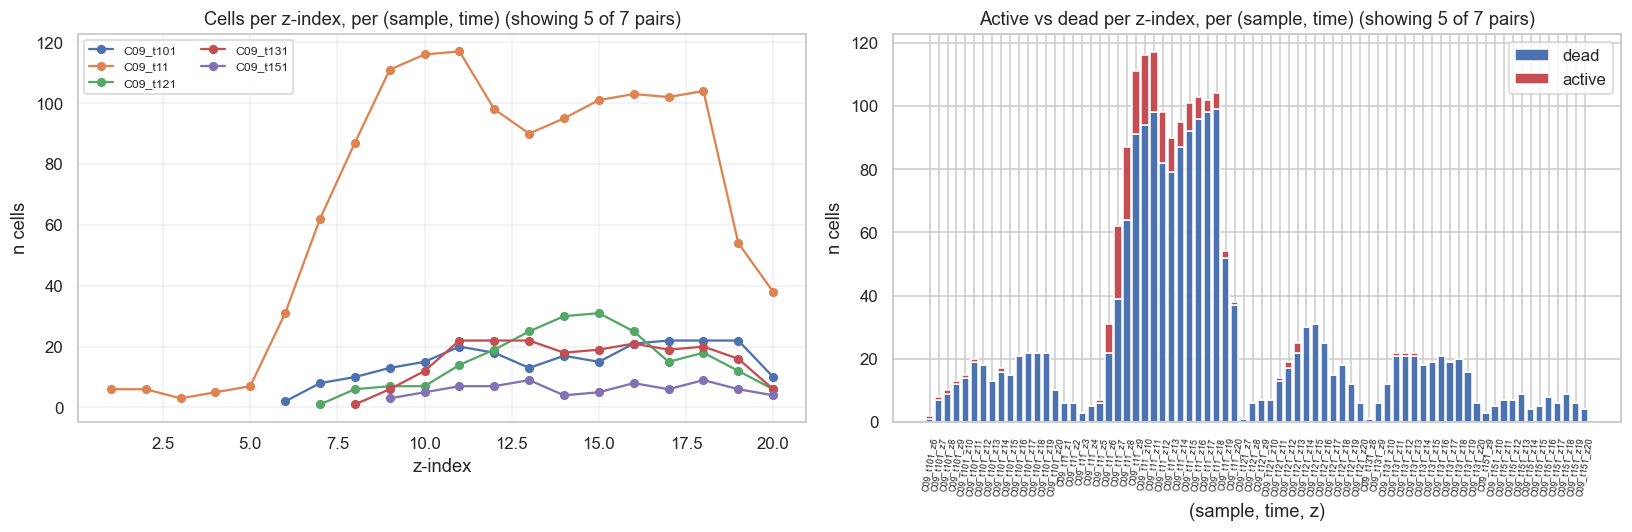

In [61]:
_ = plot_cells_per_z_by_sample_time(metrics_df)


## 5. Activity-value distributions

All distribution plots below are clipped at the `CLIP_PERCENTILE` (default 99th) of the relevant metric so that a handful of very-bright outlier cells do not squash the informative part of the histogram.

In [62]:
def _clip_series(s, q=CLIP_PERCENTILE):
    upper = s.quantile(q)
    return s.clip(lower=s.min(), upper=upper), upper


def plot_metric_value_distribution(metrics_df, q=CLIP_PERCENTILE):
    """Histogram of metric_value with active/dead overlay and threshold line(s).

    Values above the 99th percentile are clipped so the informative body of
    the distribution is visible.
    """
    clipped, upper = _clip_series(metrics_df["metric_value"], q=q)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # (a) Overall
    ax = axes[0]
    sns.histplot(clipped, bins=60, kde=True, ax=ax, color="gray", alpha=0.6)
    for thr in metrics_df["threshold"].unique():
        ax.axvline(thr, color="black", linestyle="--",
                   label=f"threshold = {thr:.2f}")
    ax.set_xlabel(f"metric_value ({threshold_metric}) — clipped at p{int(q * 100)} = {upper:.1f}")
    ax.set_ylabel("n cells")
    ax.set_title("Distribution of classifier metric")
    ax.legend()

    # (b) Density split by active / dead
    ax = axes[1]
    active_vals = clipped[metrics_df["is_active"].values]
    dead_vals = clipped[~metrics_df["is_active"].values]
    sns.histplot(dead_vals, bins=60, stat="density", color="#4C72B0", alpha=0.55,
                 label=dead_label, ax=ax)
    sns.histplot(active_vals, bins=60, stat="density", color="#C44E52", alpha=0.55,
                 label=active_label, ax=ax)
    for thr in metrics_df["threshold"].unique():
        ax.axvline(thr, color="black", linestyle="--")
    ax.set_xlabel(f"metric_value ({threshold_metric}) — clipped at p{int(q * 100)} = {upper:.1f}")
    ax.set_ylabel("density")
    ax.set_title("Active vs dead distribution")
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_intensity_metric_distributions(metrics_df, q=CLIP_PERCENTILE):
    """Per-metric histograms (active vs dead), clipped at the q-th percentile."""
    metrics_available = [
        "max_intensity", "percentile_95", "percentile_90",
        "percentile_75", "mean_intensity", "sum_intensity",
    ]
    metrics_to_plot = [m for m in metrics_available if m in metrics_df.columns]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics_to_plot):
        plot_data, upper = _clip_series(metrics_df[metric], q=q)
        active_vals = plot_data[metrics_df["is_active"].values]
        dead_vals = plot_data[~metrics_df["is_active"].values]

        ax.hist(dead_vals, bins=30, alpha=0.65, label=dead_label,
                color="#4C72B0", density=True)
        ax.hist(active_vals, bins=30, alpha=0.65, label=active_label,
                color="#C44E52", density=True)
        ax.set_xlabel(f"{metric} (clipped p{int(q * 100)}={upper:.1f})")
        ax.set_ylabel("density")
        ax.set_title(f"{metric} distribution")
        ax.legend(fontsize=8)

    for ax in axes[len(metrics_to_plot):]:
        ax.axis("off")

    fig.suptitle(
        f"Active vs dead cell distributions (clipped at p{int(q * 100)}) — thresholded by {threshold_metric}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


def plot_area_distribution(metrics_df, q=CLIP_PERCENTILE):
    """Cell-area distribution by active/dead class (clipped at q-th pct)."""
    fig, ax = plt.subplots(figsize=(9, 5))
    area_clip, upper = _clip_series(metrics_df["area"], q=q)
    data = metrics_df.copy()
    data["area"] = area_clip
    sns.histplot(data=data, x="area", hue="is_active", bins=50, kde=True,
                 palette={True: "#C44E52", False: "#4C72B0"},
                 element="step", stat="density", common_norm=False, ax=ax)
    ax.set_xlabel(f"cell area (px, clipped at p{int(q * 100)}={upper:.1f})")
    ax.set_title("Cell-area distribution by classification")
    plt.tight_layout()
    plt.show()


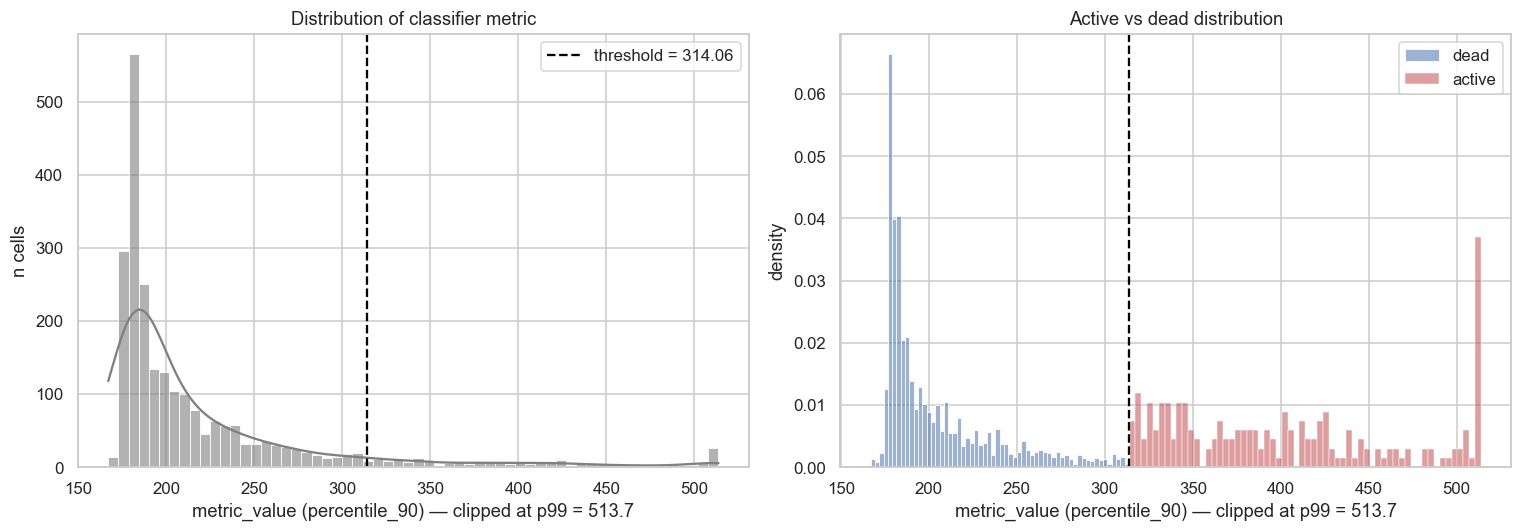

In [63]:
plot_metric_value_distribution(metrics_df)


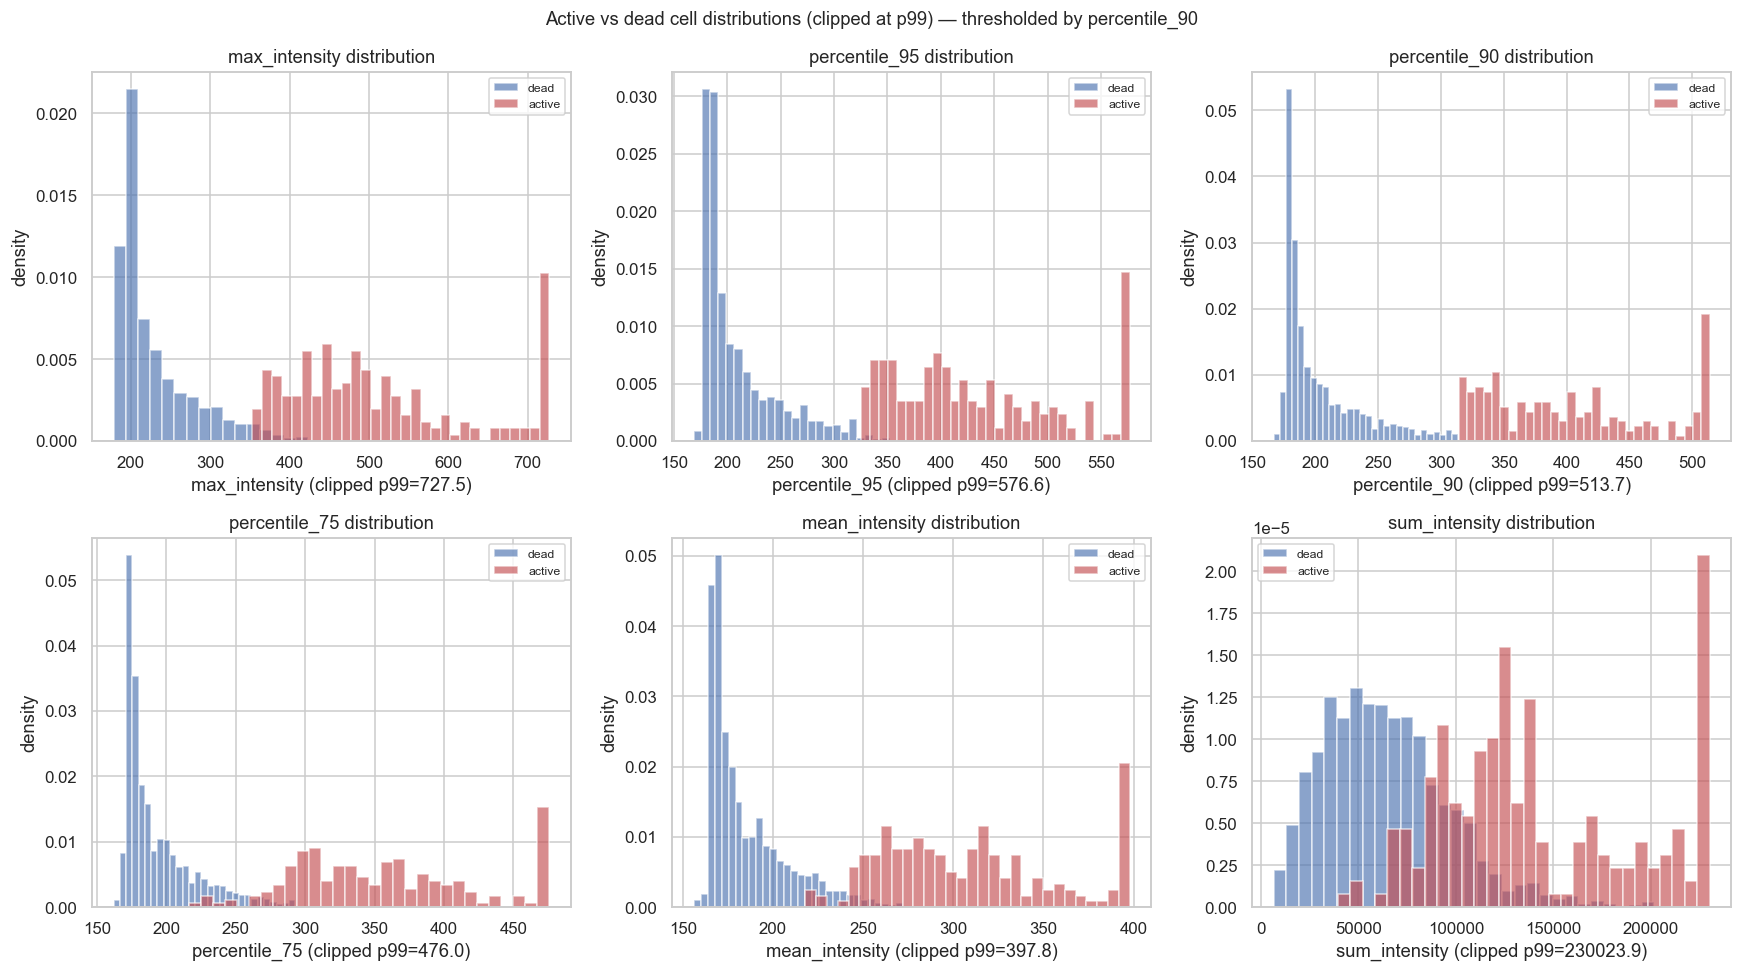

In [64]:
plot_intensity_metric_distributions(metrics_df)


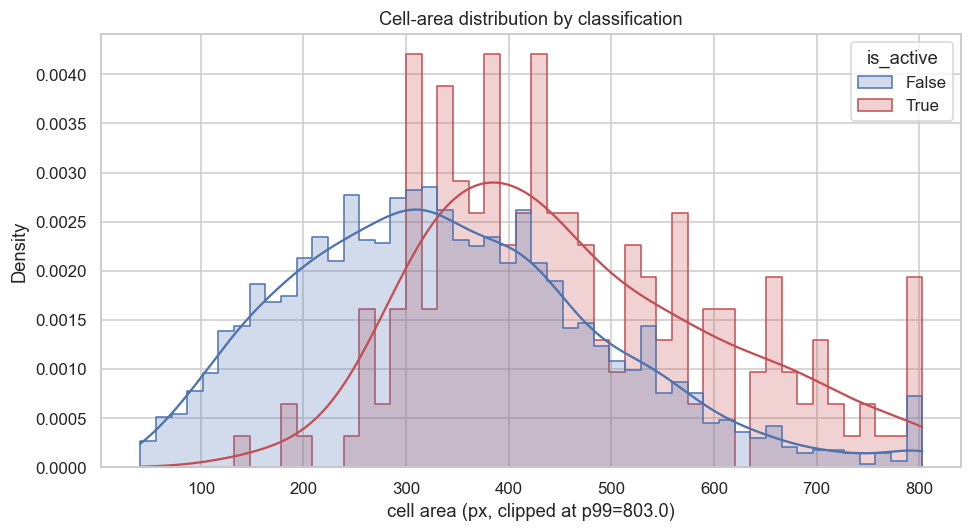

In [65]:
plot_area_distribution(metrics_df)


## 6. Analysis grouped by `z_index`

Each trace in the per-z plots corresponds to one `(sample, time)` z-stack. If there are more than `MAX_SAMPLE_TIME_PAIRS` tuples, only a subset is shown.

Metric values are clipped to the 99th percentile before plotting distributions per z.

In [66]:
def plot_z_summary_by_sample_time(metrics_df, k=MAX_SAMPLE_TIME_PAIRS):
    """Cells, active count, and activity rate per z-index, split by (sample, time)."""
    pairs = _pick_sample_time_pairs(metrics_df, k=k)
    sub = _filter_to_pairs(metrics_df, pairs)

    z_group = (sub.groupby(["sample_time", "z_index"])
                  .agg(n_cells=("label", "count"),
                       n_active=("is_active", "sum"))
                  .reset_index())
    z_group["activity_rate"] = z_group["n_active"] / z_group["n_cells"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    n_total = metrics_df[["sample", "time"]].drop_duplicates().shape[0]
    extra = f" ({len(pairs)}/{n_total} pairs)" if n_total > len(pairs) else ""

    for st, grp in z_group.groupby("sample_time"):
        grp_sorted = grp.sort_values("z_index")
        z = grp_sorted["z_index"].astype(int)
        axes[0].plot(z, grp_sorted["n_cells"], marker="o", label=st)
        axes[1].plot(z, grp_sorted["n_active"], marker="s", label=st)
        axes[2].plot(z, grp_sorted["activity_rate"] * 100, marker="^", label=st)

    axes[0].set_title(f"Cells per z-index{extra}")
    axes[0].set_xlabel("z-index"); axes[0].set_ylabel("n cells"); axes[0].grid(alpha=0.3)
    axes[1].set_title(f"Active cells per z-index{extra}")
    axes[1].set_xlabel("z-index"); axes[1].set_ylabel("n active"); axes[1].grid(alpha=0.3)
    axes[2].set_title(f"Activity rate per z-index (%){extra}")
    axes[2].set_xlabel("z-index"); axes[2].set_ylabel("% active"); axes[2].grid(alpha=0.3)
    for ax in axes:
        ax.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
    return z_group


def plot_z_variation(metrics_df, q=CLIP_PERCENTILE, k=MAX_SAMPLE_TIME_PAIRS):
    """Adapted from misc.ipynb: mean ± std per z-index for each metric.

    One trace per (sample, time) pair (down-sampled to k if too many).
    Metric values are clipped at the q-th percentile before aggregation.
    """
    pairs = _pick_sample_time_pairs(metrics_df, k=k)
    sub = _filter_to_pairs(metrics_df, pairs)
    sub = sub.dropna(subset=["z_index"]).copy()
    sub["z_index"] = sub["z_index"].astype(int)

    metrics_to_show = [
        "max_intensity", "percentile_95", "percentile_90",
        "percentile_75", "mean_intensity", "sum_intensity",
    ]
    metrics_to_show = [m for m in metrics_to_show if m in sub.columns]
    if not metrics_to_show:
        print("No metrics available to plot for per-z variation.")
        return

    # Clip each metric globally before aggregation
    for m in metrics_to_show:
        upper = metrics_df[m].quantile(q)
        sub[m] = sub[m].clip(upper=upper)

    fig, axes = plt.subplots(len(metrics_to_show), 1,
                             figsize=(11, 3 * len(metrics_to_show)), sharex=True)
    if len(metrics_to_show) == 1:
        axes = [axes]

    colors = sns.color_palette("tab10", n_colors=len(pairs))

    for ax, metric in zip(axes, metrics_to_show):
        for i, (st, grp) in enumerate(sub.groupby("sample_time")):
            agg = grp.groupby("z_index")[metric].agg(["mean", "std", "median"]).sort_index()
            std = agg["std"].fillna(0)
            zs = agg.index.values
            color = colors[i % len(colors)]
            ax.plot(zs, agg["mean"], "-o", color=color, label=f"{st} mean")
            ax.fill_between(zs, agg["mean"] - std, agg["mean"] + std,
                            color=color, alpha=0.15)
            ax.plot(zs, agg["median"], "--", color=color, linewidth=1, alpha=0.8)

        if metric == "sum_intensity":
            ax.set_yscale("log")
            ax.set_ylabel(f"{metric} (log, clipped p{int(q * 100)})")
        else:
            ax.set_ylabel(f"{metric} (clipped p{int(q * 100)})")
        ax.set_title(f"{metric}: mean ± std by z-index, per (sample, time)")
        ax.grid(alpha=0.3)
        ax.legend(loc="best", fontsize=7, ncol=2)

    axes[-1].set_xlabel("z-index")
    plt.tight_layout()
    plt.show()


def plot_metric_boxplot_by_z(metrics_df, metric="metric_value",
                             q=CLIP_PERCENTILE, k=MAX_SAMPLE_TIME_PAIRS):
    """Boxplot of a metric across z-indices, active vs dead, clipped to p99.

    Restricts to `k` (sample, time) pairs to keep the plot readable.
    """
    pairs = _pick_sample_time_pairs(metrics_df, k=k)
    sub = _filter_to_pairs(metrics_df, pairs)
    sub = sub.dropna(subset=["z_index"]).copy()
    sub["z_index"] = sub["z_index"].astype(int)
    upper = metrics_df[metric].quantile(q)
    sub[metric] = sub[metric].clip(upper=upper)

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(data=sub, x="z_index", y=metric, hue="is_active",
                palette={True: "#C44E52", False: "#4C72B0"}, ax=ax,
                showfliers=False)
    for thr in sub["threshold"].unique():
        ax.axhline(thr, color="black", linestyle="--", linewidth=1)
    n_total = metrics_df[["sample", "time"]].drop_duplicates().shape[0]
    extra = f" ({len(pairs)}/{n_total} pairs)" if n_total > len(pairs) else ""
    ax.set_title(f"{metric} by z-index (clipped p{int(q * 100)}={upper:.1f}){extra}")
    ax.set_ylabel(f"{metric} (clipped)")
    plt.tight_layout()
    plt.show()


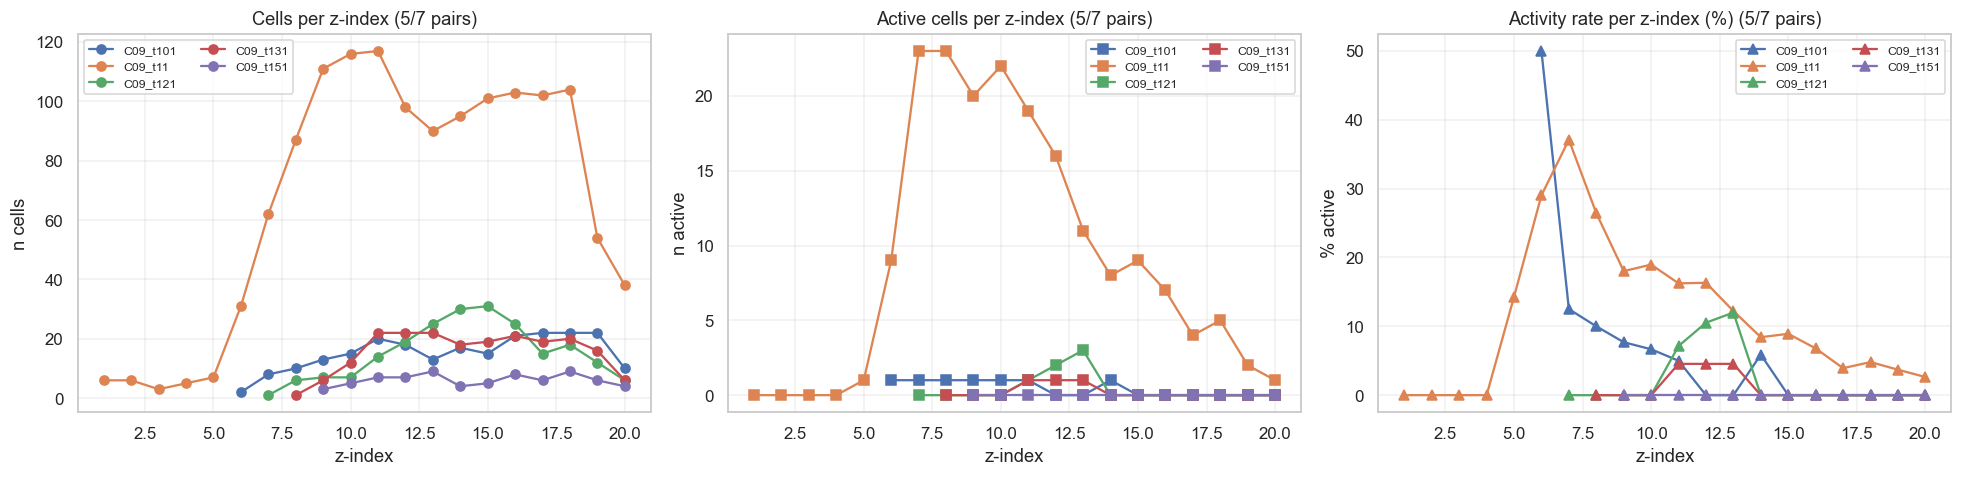

,sample_time,z_index,n_cells,n_active,activity_rate
0,C09_t101,6,2,1,0.500000
1,C09_t101,7,8,1,0.125000
2,C09_t101,8,10,1,0.100000
3,C09_t101,9,13,1,0.076923
4,C09_t101,10,15,1,0.066667


In [67]:
z_group = plot_z_summary_by_sample_time(metrics_df)
z_group.head()


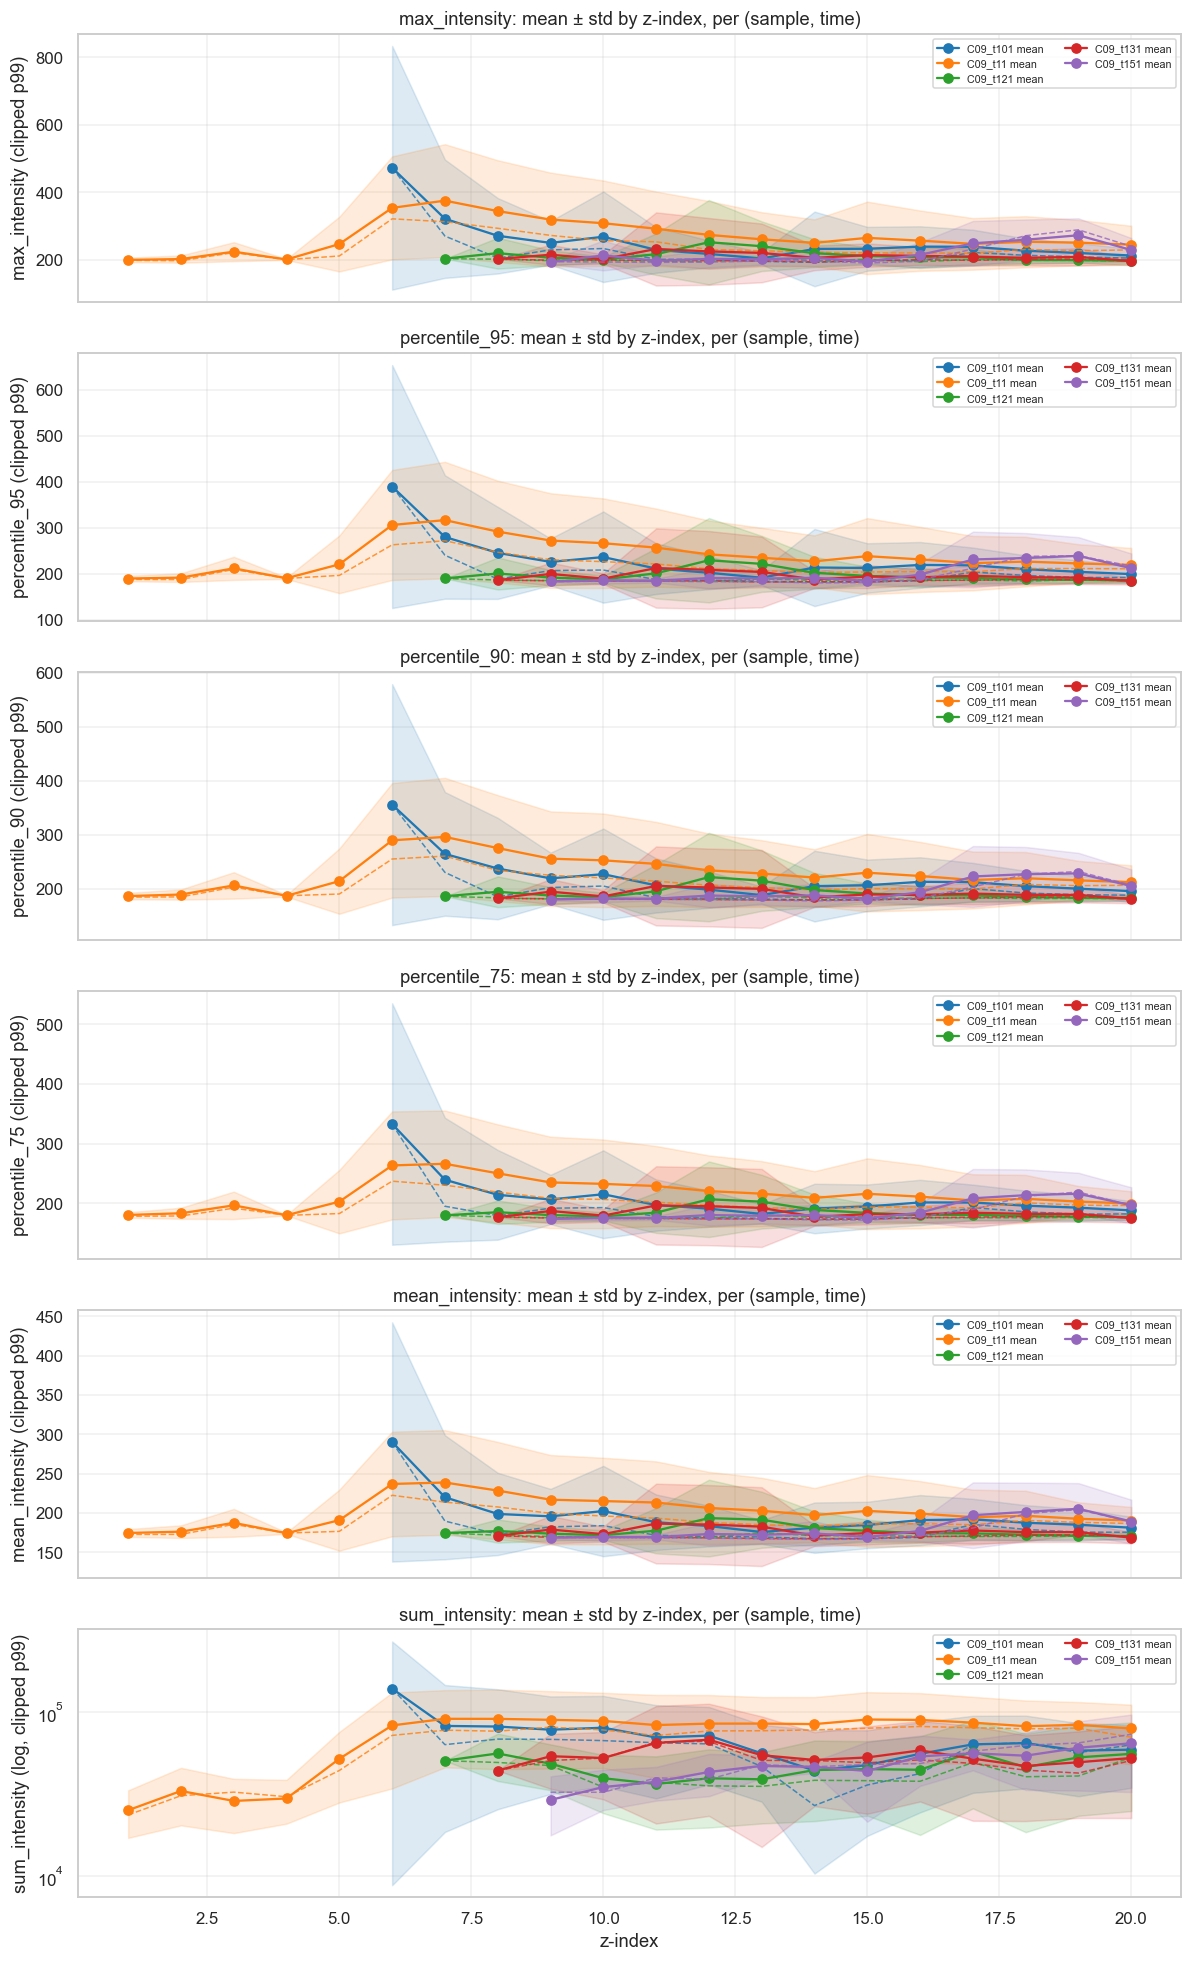

In [68]:
plot_z_variation(metrics_df)


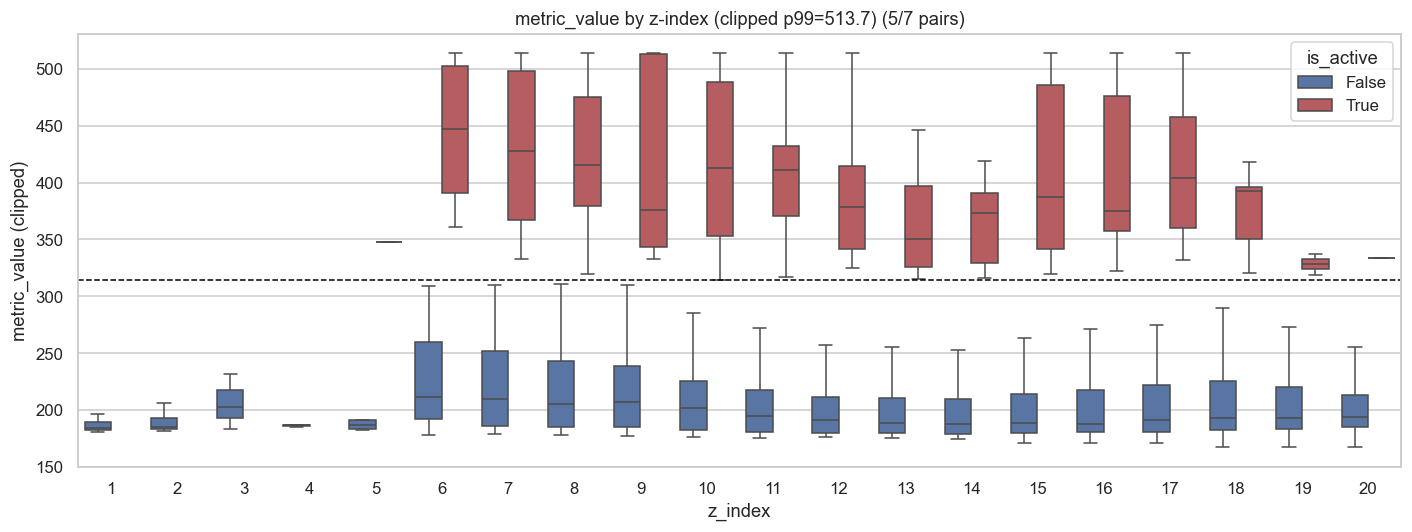

In [69]:
plot_metric_boxplot_by_z(metrics_df, metric="metric_value")


## 7. Analysis grouped by sample

Per-sample totals and distributions. Each sample aggregates across *all* time points and z-slices for that sample, so this view is complementary to the `(sample, time)` view above.

In [70]:
def plot_sample_summary(metrics_df):
    """Cell count, active count, activity rate per sample."""
    sample_stats = metrics_df.groupby("sample").agg(
        n_cells=("label", "count"),
        n_active=("is_active", "sum"),
        n_images=("image", "nunique"),
        n_times=("time", "nunique"),
        n_z=("z_index", "nunique"),
    )
    sample_stats["activity_rate"] = sample_stats["n_active"] / sample_stats["n_cells"]
    sample_stats = sample_stats.sort_values("n_cells", ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].bar(sample_stats.index, sample_stats["n_cells"], color="steelblue")
    axes[0].set_title("Total cells per sample")
    axes[0].set_ylabel("n cells")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(sample_stats.index, sample_stats["n_active"], color="#C44E52")
    axes[1].set_title("Active cells per sample")
    axes[1].set_ylabel("n active")
    axes[1].tick_params(axis="x", rotation=45)

    axes[2].bar(sample_stats.index, sample_stats["activity_rate"] * 100,
                color="#55A868")
    axes[2].set_title("Activity rate per sample (%)")
    axes[2].set_ylabel("% active")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
    return sample_stats


def plot_metric_violin_by_sample(metrics_df, metric="metric_value", q=CLIP_PERCENTILE):
    """Violin of metric values per sample, clipped at the q-th percentile."""
    upper = metrics_df[metric].quantile(q)
    plot_df = metrics_df.copy()
    plot_df[metric] = plot_df[metric].clip(upper=upper)

    fig, ax = plt.subplots(figsize=(max(8, plot_df["sample"].nunique() * 1.2), 5))
    order = sorted(plot_df["sample"].dropna().unique())
    sns.violinplot(data=plot_df, x="sample", y=metric, order=order,
                   inner="quartile", cut=0, ax=ax, color="lightgray")
    sns.stripplot(data=plot_df, x="sample", y=metric, order=order,
                  hue="is_active", palette={True: "#C44E52", False: "#4C72B0"},
                  size=2, alpha=0.4, jitter=True, ax=ax, dodge=False)
    for thr in plot_df["threshold"].unique():
        ax.axhline(thr, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{metric} per sample (clipped p{int(q * 100)}={upper:.1f})")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel(f"{metric} (clipped)")
    plt.tight_layout()
    plt.show()


def plot_activity_variation(metrics_df, q=CLIP_PERCENTILE, k=MAX_SAMPLE_TIME_PAIRS):
    """Four-panel sample×z view, keyed on (sample, time).

    Down-samples to k (sample, time) pairs and clips the metric to p99.
    """
    pairs = _pick_sample_time_pairs(metrics_df, k=k)
    sub = _filter_to_pairs(metrics_df, pairs).copy()
    upper = metrics_df["metric_value"].quantile(q)
    sub["metric_value"] = sub["metric_value"].clip(upper=upper)

    sample_z_summary = (sub.groupby(["sample_time", "z_index"])
                           .agg(n_cells=("label", "count"),
                                n_active=("is_active", "sum"),
                                activity_rate=("is_active", "mean"),
                                median_metric=("metric_value", "median"),
                                mean_metric=("metric_value", "mean"),
                                threshold=("threshold", "first"))
                           .reset_index())

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 11))

    st_ids = sorted(sub["sample_time"].dropna().unique())

    # (1) Activity rate by z-index, per (sample, time)
    for st in st_ids:
        subset = sample_z_summary[sample_z_summary["sample_time"] == st].sort_values("z_index")
        ax1.plot(subset["z_index"], subset["activity_rate"] * 100,
                 marker="o", linewidth=1.5, markersize=5, label=st)
    ax1.set_xlabel("z-index"); ax1.set_ylabel("activity rate (%)")
    ax1.set_title("Activity rate by z-index, per (sample, time)")
    ax1.grid(True, alpha=0.3); ax1.legend(fontsize=8, ncol=2)

    # (2) Metric violin by sample_time × z (already down-sampled)
    tmp = sub.copy()
    tmp["st_z"] = tmp["sample_time"].astype(str) + "_z" + tmp["z_index"].astype(str)
    order = (tmp[["sample_time", "z_index", "st_z"]]
             .drop_duplicates()
             .sort_values(["sample_time", "z_index"])["st_z"].tolist())

    subsampled = []
    for sz in order:
        chunk = tmp[tmp["st_z"] == sz]
        if len(chunk) > 50:
            chunk = chunk.sample(n=50, random_state=42)
        subsampled.append(chunk)
    subsampled_df = pd.concat(subsampled, ignore_index=True)

    sns.violinplot(data=subsampled_df, x="st_z", y="metric_value",
                   order=order, ax=ax2, inner="quartile", cut=0, color="lightgray")
    ax2.scatter(range(len(order)),
                [subsampled_df.loc[subsampled_df["st_z"] == sz, "threshold"].iloc[0]
                 for sz in order],
                color="black", marker="_", s=80, linewidth=2, label="threshold", zorder=5)
    ax2.set_xticks(range(len(order)))
    ax2.set_xticklabels(order, rotation=80, ha="right", fontsize=6)
    ax2.set_ylabel(f"metric_value (clipped p{int(q * 100)}={upper:.1f})")
    ax2.set_title("Metric distribution by (sample, time) × z-index")
    ax2.legend(fontsize=8)

    # (3) n_cells by z-index, per (sample, time)
    for st in st_ids:
        subset = sample_z_summary[sample_z_summary["sample_time"] == st].sort_values("z_index")
        ax3.plot(subset["z_index"], subset["n_cells"],
                 marker="s", linewidth=1.5, markersize=5, label=st)
    ax3.set_xlabel("z-index"); ax3.set_ylabel("n cells")
    ax3.set_title("Cell count by z-index, per (sample, time)")
    ax3.grid(True, alpha=0.3); ax3.legend(fontsize=8, ncol=2)

    # (4) Activity-rate heatmap (rows = sample_time, cols = z)
    heatmap_data = sample_z_summary.pivot(index="sample_time", columns="z_index",
                                          values="activity_rate")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlBu_r",
                cbar_kws={"label": "activity rate"}, ax=ax4,
                annot_kws={"fontsize": 6})
    ax4.set_title("Activity-rate heatmap ((sample, time) × z-index)")
    ax4.set_xlabel("z-index"); ax4.set_ylabel("(sample, time)")

    plt.tight_layout()
    plt.show()

    # Text summary
    print("\n=== (sample, time) SUMMARY ===")
    for st in st_ids:
        stats = sample_z_summary[sample_z_summary["sample_time"] == st]
        print(f"\n{st}:")
        print(f"  z-index range:       {stats['z_index'].min()}–{stats['z_index'].max()}")
        print(f"  total cells:         {stats['n_cells'].sum()}")
        print(f"  mean activity rate:  {stats['activity_rate'].mean():.1%}")
        print(f"  activity rate range: {stats['activity_rate'].min():.1%} – {stats['activity_rate'].max():.1%}")

    return sample_z_summary


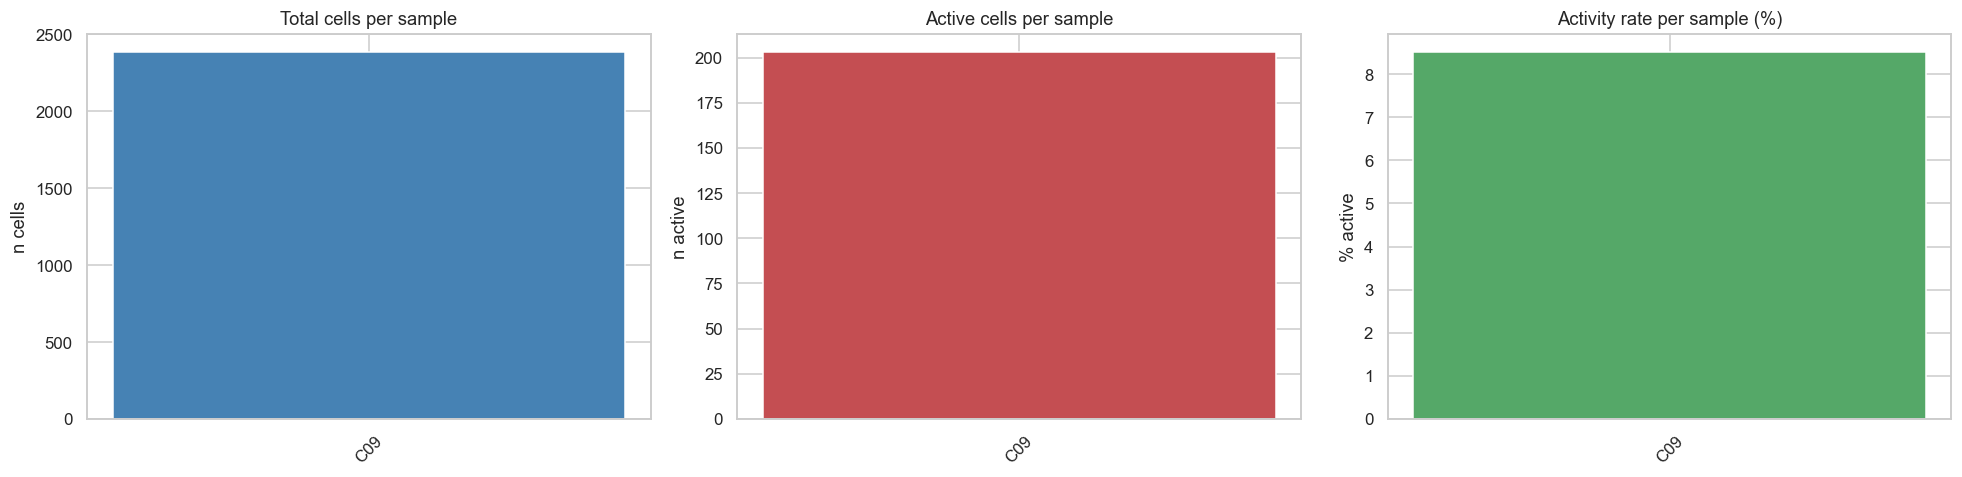

,n_cells,n_active,n_images,n_times,n_z,activity_rate
sample,,,,,,
C09,2385,203,107,7,20,0.085115


In [71]:
sample_stats = plot_sample_summary(metrics_df)
sample_stats


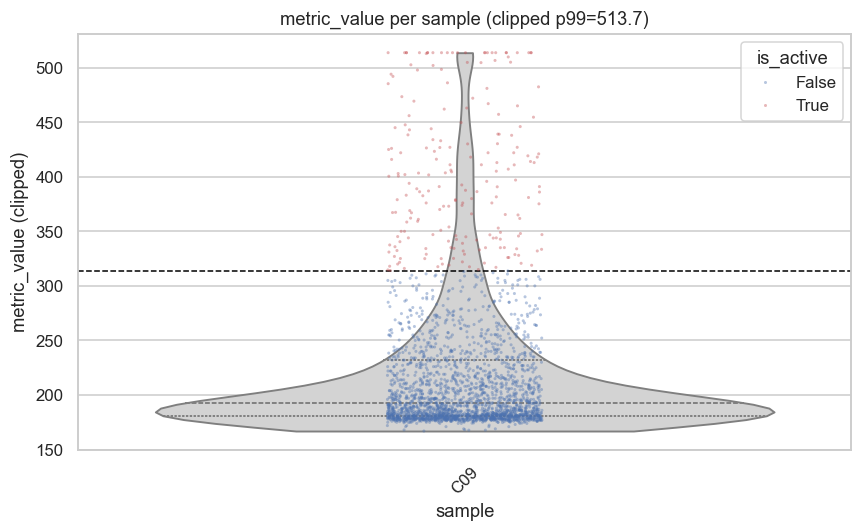

In [72]:
plot_metric_violin_by_sample(metrics_df, metric="metric_value")


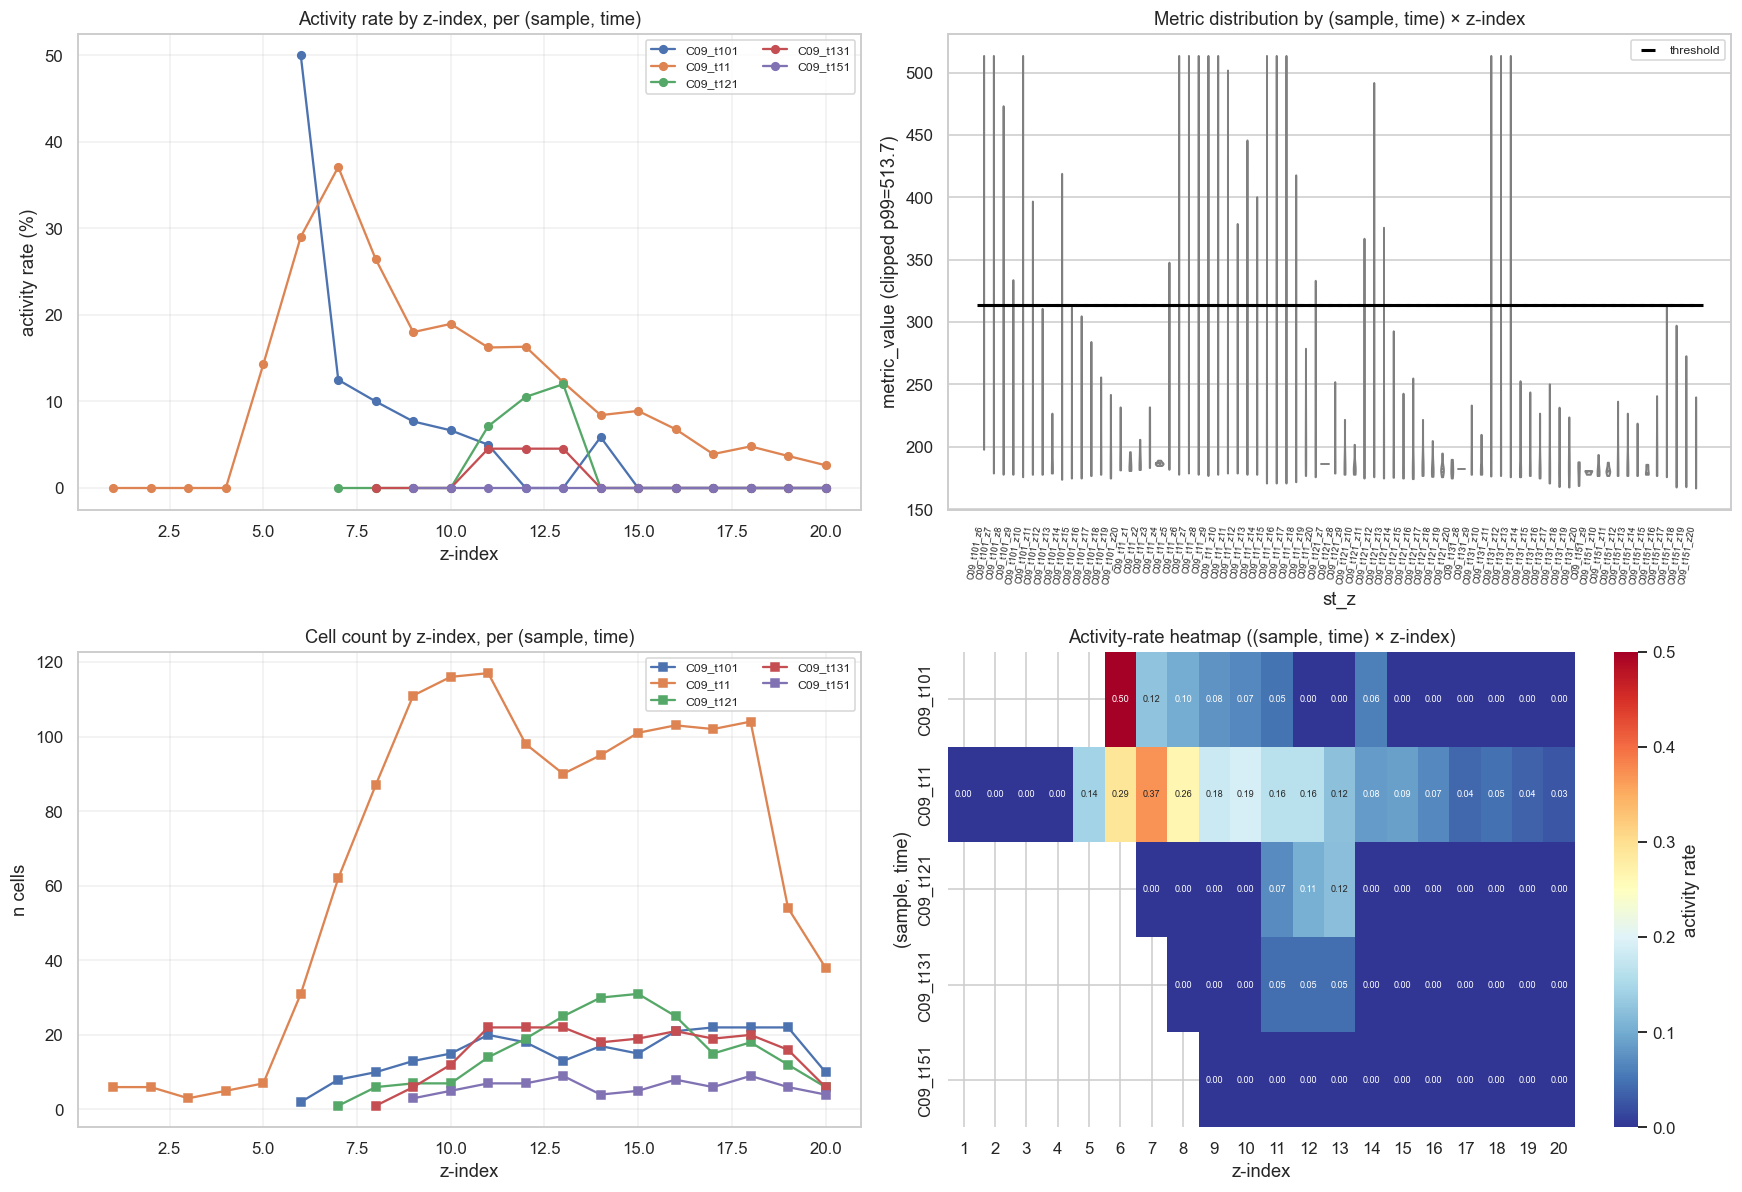


=== (sample, time) SUMMARY ===

C09_t101:
  z-index range:       6–20
  total cells:         228
  mean activity rate:  6.5%
  activity rate range: 0.0% – 50.0%

C09_t11:
  z-index range:       1–20
  total cells:         1336
  mean activity rate:  11.4%
  activity rate range: 0.0% – 37.1%

C09_t121:
  z-index range:       7–20
  total cells:         216
  mean activity rate:  2.1%
  activity rate range: 0.0% – 12.0%

C09_t131:
  z-index range:       8–20
  total cells:         204
  mean activity rate:  1.0%
  activity rate range: 0.0% – 4.5%

C09_t151:
  z-index range:       9–20
  total cells:         73
  mean activity rate:  0.0%
  activity rate range: 0.0% – 0.0%


,sample_time,z_index,n_cells,n_active,activity_rate,median_metric,mean_metric,threshold
0,C09_t101,6,2,1,0.500000,355.858,355.858000,314.059766
1,C09_t101,7,8,1,0.125000,230.300,264.552000,314.059766
2,C09_t101,8,10,1,0.100000,185.000,237.420000,314.059766
3,C09_t101,9,13,1,0.076923,202.300,219.253846,314.059766
4,C09_t101,10,15,1,0.066667,205.000,226.967733,314.059766


In [73]:
sample_z_summary = plot_activity_variation(metrics_df)
sample_z_summary.head()


## 8. Time-ordered statistics

Check whether the metrics drift over time. Each plot orders values by `time` (within each sample where applicable) to expose temporal trends.

In [74]:
def time_statistics(metrics_df):
    """Return a dataframe of per-(sample, time) summary statistics ordered by time."""
    stats = (metrics_df.groupby(["sample", "time"])
                       .agg(n_cells=("label", "count"),
                            n_active=("is_active", "sum"),
                            mean_metric=("metric_value", "mean"),
                            median_metric=("metric_value", "median"),
                            std_metric=("metric_value", "std"),
                            threshold=("threshold", "first"))
                       .reset_index())
    stats["n_dead"] = stats["n_cells"] - stats["n_active"]
    stats["activity_rate"] = stats["n_active"] / stats["n_cells"]
    return stats.sort_values(["sample", "time"])


def plot_time_trends(metrics_df, q=CLIP_PERCENTILE):
    """Plot per-sample time series of n_cells, activity_rate, and metric summary stats."""
    stats = time_statistics(metrics_df)

    if stats["time"].nunique() < 2:
        print(f"Only {stats['time'].nunique()} unique time point(s) "
              f"({sorted(stats['time'].unique())}). "
              "Temporal trend plots are omitted; the per-(sample, time) stats are shown below instead.")
        return stats

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    for sample, grp in stats.groupby("sample"):
        axes[0, 0].plot(grp["time"], grp["n_cells"], "-o", label=sample)
        axes[0, 1].plot(grp["time"], grp["activity_rate"] * 100, "-o", label=sample)
        axes[1, 0].plot(grp["time"], grp["median_metric"], "-o", label=sample)
        axes[1, 1].plot(grp["time"], grp["std_metric"], "-o", label=sample)

    axes[0, 0].set_title("Cells over time"); axes[0, 0].set_ylabel("n cells")
    axes[0, 1].set_title("Activity rate over time"); axes[0, 1].set_ylabel("% active")
    axes[1, 0].set_title("Median metric_value over time"); axes[1, 0].set_ylabel("median")
    axes[1, 1].set_title("Std of metric_value over time"); axes[1, 1].set_ylabel("std")

    for ax in axes.ravel():
        ax.set_xlabel("time")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
    return stats


def plot_metric_box_by_time(metrics_df, metric="metric_value", q=CLIP_PERCENTILE):
    """Boxplot of the classifier metric grouped by time, ordered chronologically."""
    if metrics_df["time"].nunique() < 2:
        print(f"Only one time point present ({metrics_df['time'].unique().tolist()}); "
              "boxplot over time would be a single box — skipped.")
        return

    upper = metrics_df[metric].quantile(q)
    plot_df = metrics_df.copy()
    plot_df[metric] = plot_df[metric].clip(upper=upper)
    order = sorted(plot_df["time"].dropna().unique())

    fig, ax = plt.subplots(figsize=(max(8, len(order) * 0.8), 5))
    sns.boxplot(data=plot_df, x="time", y=metric, hue="is_active",
                order=order, palette={True: "#C44E52", False: "#4C72B0"},
                showfliers=False, ax=ax)
    for thr in plot_df["threshold"].unique():
        ax.axhline(thr, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{metric} over time (clipped p{int(q * 100)}={upper:.1f})")
    ax.set_ylabel(f"{metric} (clipped)")
    plt.tight_layout()
    plt.show()


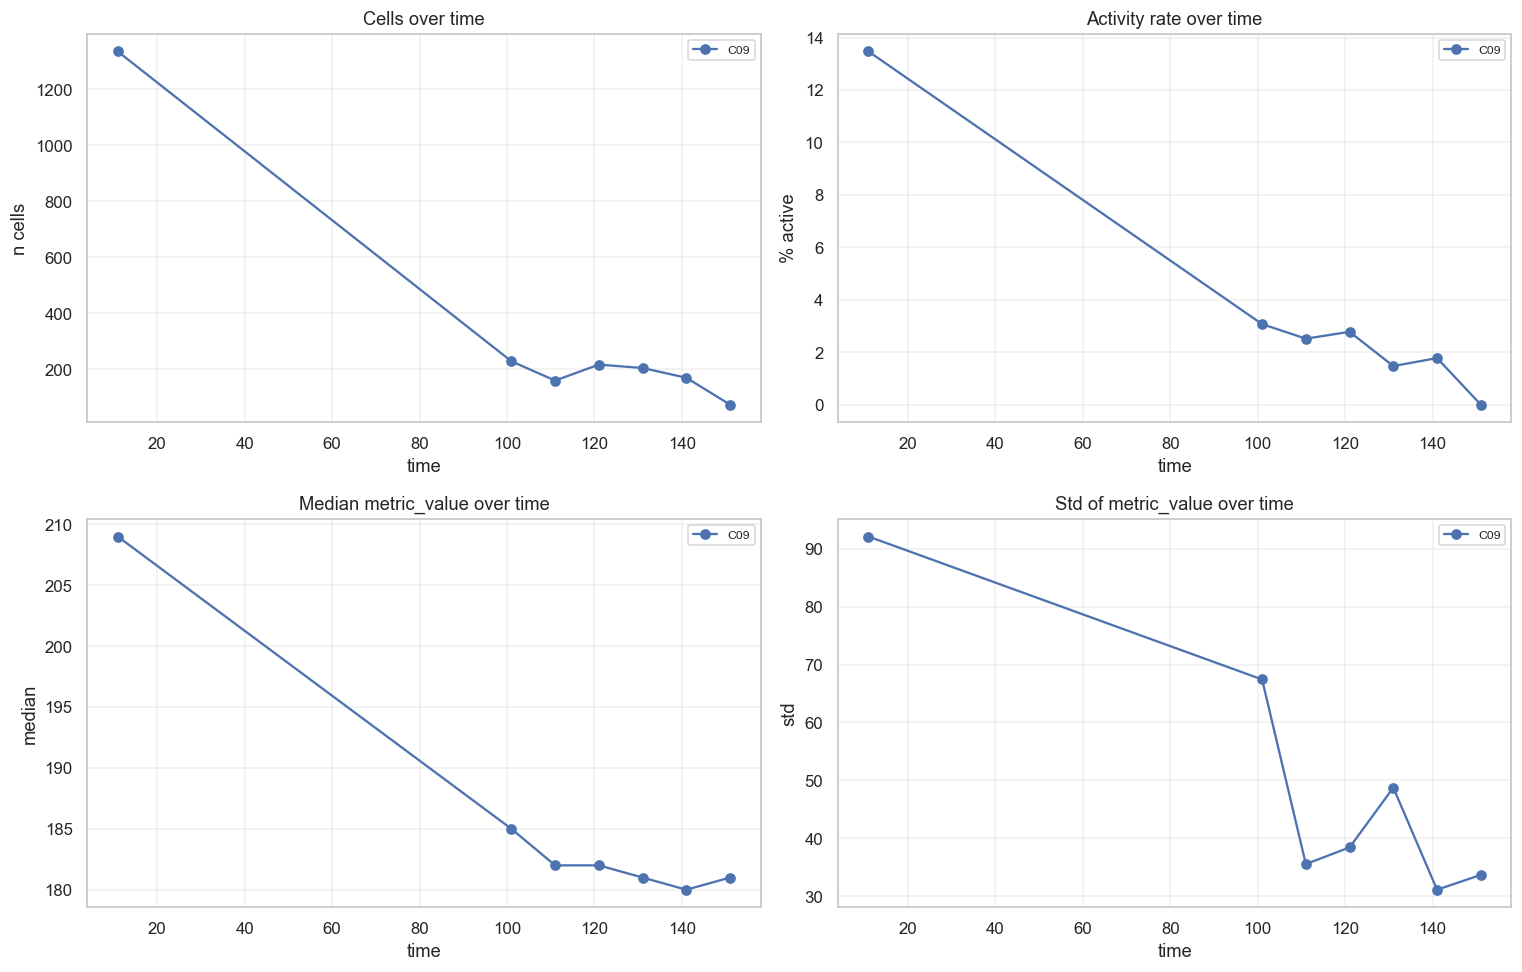

,sample,time,n_cells,n_active,mean_metric,median_metric,std_metric,threshold,n_dead,activity_rate
0,C09,11,1336,180,241.074850,209.0,92.100739,314.059766,1156,0.134731
1,C09,101,228,7,213.078509,185.0,67.414973,314.059766,221,0.030702
2,C09,111,159,4,196.110692,182.0,35.539113,314.059766,155,0.025157
3,C09,121,216,6,195.637500,182.0,38.410724,314.059766,210,0.027778
4,C09,131,204,3,193.411275,181.0,48.737245,314.059766,201,0.014706
5,C09,141,169,3,192.029586,180.0,31.111175,314.059766,166,0.017751
6,C09,151,73,0,198.365753,181.0,33.671564,314.059766,73,0.000000


In [75]:
time_stats = plot_time_trends(metrics_df)
time_stats


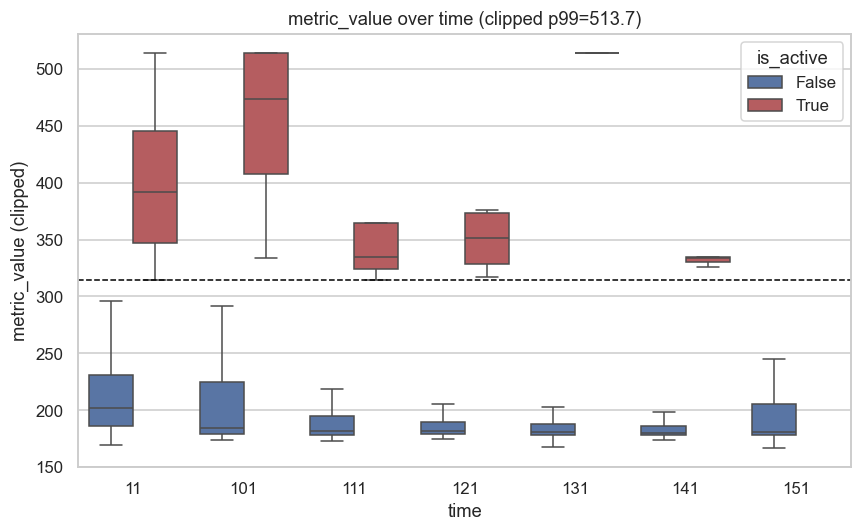

In [76]:
plot_metric_box_by_time(metrics_df, metric="metric_value")


## 9. Per-image summary analysis

Uses the summary CSV directly to look at `percent_active`, `metric_median`, and `metric_std` across images, ordered by `(sample, time, z)`.

In [78]:
def plot_summary_analysis(summary, q=CLIP_PERCENTILE):
    """Distribution and per-image plots derived from the summary CSV."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # (a) Percent active distribution across images
    ax = axes[0, 0]
    sns.histplot(summary["percent_active"], bins=20, kde=True, ax=ax, color="#55A868")
    ax.axvline(summary["percent_active"].mean(), color="red", linestyle="--",
               label=f"mean = {summary['percent_active'].mean():.1f}%")
    ax.set_xlabel("% active cells per image")
    ax.set_ylabel("n images")
    ax.set_title("Distribution of activity rate per image")
    ax.legend()

    # (b) n_instances vs percent_active scatter (colour by sample_time)
    ax = axes[0, 1]
    hue = "sample_time" if summary["sample_time"].nunique() <= 15 else None
    sns.scatterplot(data=summary, x="n_instances", y="percent_active",
                    hue=hue, ax=ax)
    ax.set_xlabel("cells per image (n_instances)")
    ax.set_ylabel("% active")
    ax.set_title("Image cell-count vs activity rate")

    # (c) metric_median vs threshold_used, clipped for the median
    ax = axes[1, 0]
    med_upper = summary["metric_median"].quantile(q)
    plot_df = summary.copy()
    plot_df["metric_median"] = plot_df["metric_median"].clip(upper=med_upper)
    sns.scatterplot(data=plot_df, x="threshold_used", y="metric_median",
                    hue=hue, ax=ax)
    ax.plot([plot_df["threshold_used"].min(), plot_df["threshold_used"].max()],
            [plot_df["threshold_used"].min(), plot_df["threshold_used"].max()],
            linestyle=":", color="black", linewidth=1, label="y = x")
    ax.set_xlabel("threshold_used")
    ax.set_ylabel(f"metric_median (clipped p{int(q * 100)}={med_upper:.1f})")
    ax.set_title("Image-level metric median vs threshold")
    ax.legend(fontsize=8)

    # (d) % active per image ordered by (sample, time, z)
    ax = axes[1, 1]
    ordered = summary.sort_values(["sample", "time", "z_index"]).reset_index(drop=True)
    colors = ["#55A868" if x > 50 else "#C44E52" if x < 20 else "#DD8452"
              for x in ordered["percent_active"]]
    ax.bar(range(len(ordered)), ordered["percent_active"], color=colors)
    ax.set_xticks(range(len(ordered)))
    ax.set_xticklabels(ordered["image"], rotation=80, ha="right", fontsize=6)
    ax.set_ylabel("% active")
    ax.set_title("% active cells per image (ordered by sample, time, z)")

    plt.tight_layout()
    plt.show()


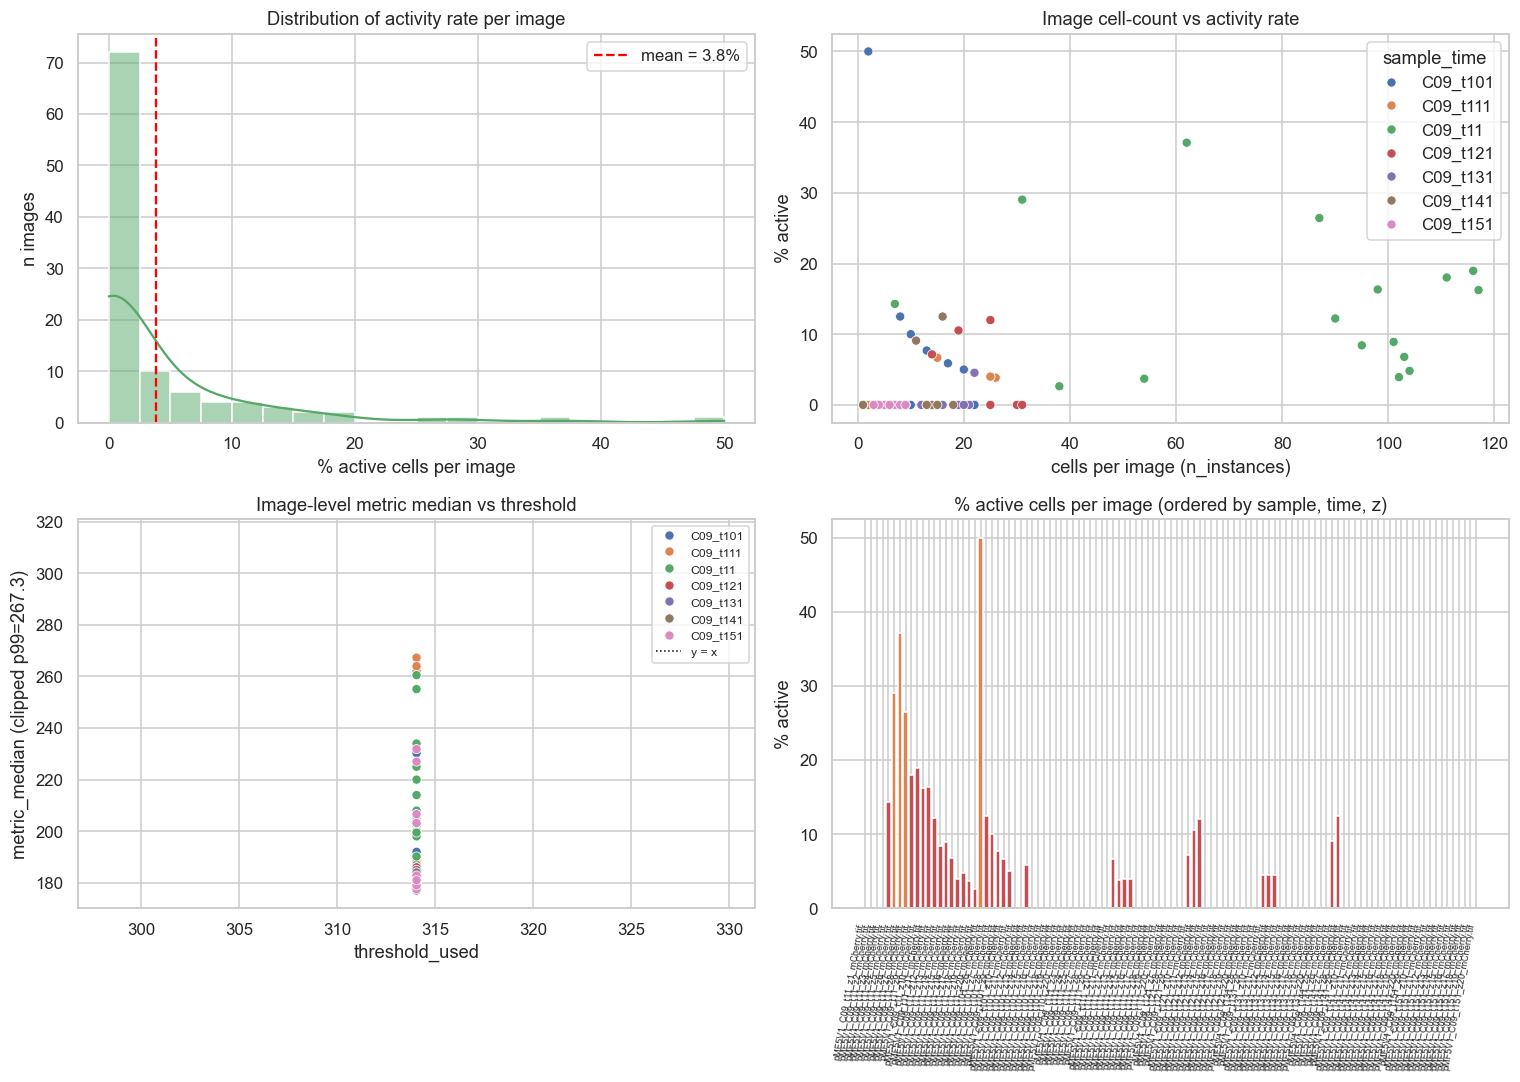

In [79]:
plot_summary_analysis(summary)


## 10. Notes

- Aggregations are keyed on `(sample, time)` tuples (`sample_time`) rather than across the whole dataset, so time-lapse data is not accidentally pooled.
- `CLIP_PERCENTILE` (default 99%) controls the upper clip applied to metric values before plotting distributions.
- `MAX_SAMPLE_TIME_PAIRS` (default 5) controls down-sampling of `(sample, time)` pairs in dense plots (per-z traces, z-boxplots, `plot_activity_variation`). Increase it if you want to see every pair.
- All helpers are parameterised so you can re-run on a different classifier output by editing only the two paths at the top.
- For napari-based spatial inspection, see `misc.ipynb`.